# Project Tasks

In the first two assignments, we have learned how to infer part based components (known as mutational signatures) generated by particular mutational processes using Non-negative Matrix Factorization (NMF). By doing this, we are trying to reconstruct the mutation catalog in a given sample with mutational signatures and their contributions.

In this group project, you will use similar mutational profiles and signature activities to predict cancer types but with much larger sample size. 
You should:
* Separate the data into training and test groups within each cancer type.
* Find out which features are informative for the prediction of the cancer type (label). You should try both combining the profiles with activities and using each data type independently.
* Implement different models of your choice for classification of the samples given the input data and evaluate the model performance using test data to avoid overfitting. Explain briefly how does each model that you have used work.
* Report model performance, using standard machine learning metrics such as confusion matrices etc. 
* Compare model performance across methods and across cancer types, are some types easier to predict than others.
* Submit a single Jupyter notebook as the final report and present that during the last assignment session.

# Data

The data include both mutational catalogs from multiple cancers and the predicted activities in the paper ["Alexandrov LB, et al. (2020) The repertoire of mutational signatures in human cancer"](https://www.nature.com/articles/s41586-020-1943-3). The data either are generated from whole human genome (WGS) or only exomes regions (WES). Since the exome region only constitutes about 1% of human genome, the total mutation numbers in these samples are, of course, much smaller. So if you plan to use WGS together with WES data, remember to normalize the profile for each sample to sum up to 1.

Note that, the data is generated from different platforms by different research groups, some of them (e.g. labeled with PCAWG, TCGA) are processed with the same bioinformatics pipeline. Thus, these samples will have less variability related to data processing pipelines.

Cancer types might be labeled under the same tissue, e.g. 'Bone-Benign','Bone-Epith', which can also be combined together or take the one has more samples.

Here is a link to background reading ["Pan-Cancer Analysis of Whole Genomes"](https://www.nature.com/collections/afdejfafdb). Have a look especially at the paper ["A deep learning system accurately classifies primary and metastatic cancers using passenger mutation patterns"](https://www.nature.com/articles/s41467-019-13825-8).

In [1]:
import pandas as pd
import re

## Mutational catalogs and activities - WGS data

In [2]:
## PCAWG data is performed by the same pipeline
PCAWG_wgs_mut = pd.read_csv ("./project_data/catalogs/WGS/WGS_PCAWG.96.csv")
PCAWG_wgs_mut.head(2)

,Mutation type,Trinucleotide,Biliary-AdenoCA::SP117655,Biliary-AdenoCA::SP117556,Biliary-AdenoCA::SP117627,Biliary-AdenoCA::SP117775,Biliary-AdenoCA::SP117332,Biliary-AdenoCA::SP117712,Biliary-AdenoCA::SP117017,Biliary-AdenoCA::SP117031,...,Uterus-AdenoCA::SP94540,Uterus-AdenoCA::SP95222,Uterus-AdenoCA::SP89389,Uterus-AdenoCA::SP90503,Uterus-AdenoCA::SP92460,Uterus-AdenoCA::SP92931,Uterus-AdenoCA::SP91265,Uterus-AdenoCA::SP89909,Uterus-AdenoCA::SP90629,Uterus-AdenoCA::SP95550
0,C>A,ACA,269,114,105,217,52,192,54,196,...,117,233,94,114,257,139,404,97,250,170
1,C>A,ACC,148,56,71,123,36,139,54,102,...,90,167,59,64,268,75,255,78,188,137


Accuracy is the cosine similarity of reconstruct catalog to the observed catalog 

In [3]:
## Activities:
PCAWG_wgs_act = pd.read_csv ("./project_data/activities/WGS/WGS_PCAWG.activities.csv")
PCAWG_wgs_act.head(2)

,Cancer Types,Sample Names,Accuracy,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS7a,...,SBS51,SBS52,SBS53,SBS54,SBS55,SBS56,SBS57,SBS58,SBS59,SBS60
0,Biliary-AdenoCA,SP117655,0.968,1496,1296,0,0,1825,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Biliary-AdenoCA,SP117556,0.963,985,0,0,0,922,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
nonPCAWG_wgs_mut = pd.read_csv ("./project_data/catalogs/WGS/WGS_Other.96.csv")
nonPCAWG_wgs_mut.head(2)

,Mutation type,Trinucleotide,ALL::PD4020a,ALL::SJBALL011_D,ALL::SJBALL012_D,ALL::SJBALL020013_D1,ALL::SJBALL020422_D1,ALL::SJBALL020579_D1,ALL::SJBALL020589_D1,ALL::SJBALL020625_D1,...,Stomach-AdenoCa::pfg316T,Stomach-AdenoCa::pfg317T,Stomach-AdenoCa::pfg344T,Stomach-AdenoCa::pfg373T,Stomach-AdenoCa::pfg375T,Stomach-AdenoCa::pfg378T,Stomach-AdenoCa::pfg398T,Stomach-AdenoCa::pfg413T,Stomach-AdenoCa::pfg416T,Stomach-AdenoCa::pfg424T
0,C>A,ACA,35,9,2,7,5,7,3,5,...,133,185,202,185,96,134,12,279,75,135
1,C>A,ACC,16,2,4,10,5,9,1,2,...,48,70,126,88,35,54,16,112,31,91


In [5]:
nonPCAWG_wgs_act = pd.read_csv ("./project_data/activities/WGS/WGS_Other.activities.csv")
nonPCAWG_wgs_act.head(2)

,Cancer Types,Sample Names,Accuracy,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS7a,...,SBS51,SBS52,SBS53,SBS54,SBS55,SBS56,SBS57,SBS58,SBS59,SBS60
0,ALL,PD4020a,0.995,208,3006,0,0,365,0,0,...,0,0,0,0,0,0,0,0,0,0
1,ALL,SJBALL011_D,0.905,66,0,0,0,144,0,0,...,0,0,0,0,0,0,0,0,0,0


## Mutational catalogs - WES data

In [6]:
## Performed by TCGA pipeline
TCGA_wes_mut = pd.read_csv ("./project_data/catalogs/WES/WES_TCGA.96.csv")
TCGA_wes_mut.head(2)

,Mutation type,Trinucleotide,AML::TCGA-AB-2802-03B-01W-0728-08,AML::TCGA-AB-2803-03B-01W-0728-08,AML::TCGA-AB-2804-03B-01W-0728-08,AML::TCGA-AB-2805-03B-01W-0728-08,AML::TCGA-AB-2806-03B-01W-0728-08,AML::TCGA-AB-2807-03B-01W-0728-08,AML::TCGA-AB-2808-03B-01W-0728-08,AML::TCGA-AB-2809-03D-01W-0755-09,...,Eye-Melanoma::TCGA-WC-A885-01A-11D-A39W-08,Eye-Melanoma::TCGA-WC-A888-01A-11D-A39W-08,Eye-Melanoma::TCGA-WC-A88A-01A-11D-A39W-08,Eye-Melanoma::TCGA-WC-AA9A-01A-11D-A39W-08,Eye-Melanoma::TCGA-WC-AA9E-01A-11D-A39W-08,Eye-Melanoma::TCGA-YZ-A980-01A-11D-A39W-08,Eye-Melanoma::TCGA-YZ-A982-01A-11D-A39W-08,Eye-Melanoma::TCGA-YZ-A983-01A-11D-A39W-08,Eye-Melanoma::TCGA-YZ-A984-01A-11D-A39W-08,Eye-Melanoma::TCGA-YZ-A985-01A-11D-A39W-08
0,C>A,ACA,0,0,0,0,4,0,2,0,...,1,0,0,0,0,0,0,0,0,0
1,C>A,ACC,0,2,0,0,0,1,3,0,...,0,0,0,0,0,0,0,1,0,0


In [7]:
##Activities
TCGA_wes_act = pd.read_csv("./project_data/activities/WES/WES_TCGA.activities.csv")
TCGA_wes_act.head(2)

,Cancer Types,Sample Names,Accuracy,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS7a,...,SBS51,SBS52,SBS53,SBS54,SBS55,SBS56,SBS57,SBS58,SBS59,SBS60
0,AML,TCGA-AB-2802-03B-01W-0728-08,0.811,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,AML,TCGA-AB-2803-03B-01W-0728-08,0.608,4,0,0,0,7,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
other_wes_mut = pd.read_csv("./project_data/catalogs/WES/WES_Other.96.csv")
other_wes_mut.head(2)

,Mutation type,Trinucleotide,ALL::TARGET-10-PAIXPH-03A-01D,ALL::TARGET-10-PAKHZT-03A-01R,ALL::TARGET-10-PAKMVD-09A-01D,ALL::TARGET-10-PAKSWW-03A-01D,ALL::TARGET-10-PALETF-03A-01D,ALL::TARGET-10-PALLSD-09A-01D,ALL::TARGET-10-PAMDKS-03A-01D,ALL::TARGET-10-PAPJIB-04A-01D,...,Head-SCC::V-109,Head-SCC::V-112,Head-SCC::V-116,Head-SCC::V-119,Head-SCC::V-123,Head-SCC::V-124,Head-SCC::V-125,Head-SCC::V-14,Head-SCC::V-29,Head-SCC::V-98
0,C>A,ACA,0,0,0,1,0,0,0,2,...,0,0,0,0,0,0,0,0,0,1
1,C>A,ACC,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0


In [9]:
other_wes_act = pd.read_csv("./project_data/activities/WES/WES_Other.activities.csv")
other_wes_act.head(2)

,Cancer Types,Sample Names,Accuracy,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS7a,...,SBS51,SBS52,SBS53,SBS54,SBS55,SBS56,SBS57,SBS58,SBS59,SBS60
0,ALL,TARGET-10-PAIXPH-03A-01D,0.529,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,ALL,TARGET-10-PAKHZT-03A-01R,0.696,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [10]:
import pandas as pd

def melt_mutation_catalog(mut_df, dataset_name=""):
    """
    mut_df: shape (96, n_samples+2) with first two columns ['Mutation type','Trinucleotide']
    returns: long table with columns:
        ['Mutation type','Trinucleotide','full_sample','Cancer Types','Sample Names','count']
    """
    id_cols = ["Mutation type", "Trinucleotide"]
    value_cols = [c for c in mut_df.columns if c not in id_cols]

    long_df = mut_df.melt(
        id_vars=id_cols,
        value_vars=value_cols,
        var_name="full_sample",
        value_name="count"
    )

    # full_sample looks like "Biliary-AdenoCA::SP117655"
    # split into Cancer Types and Sample Names
    split = long_df["full_sample"].str.split("::", n=1, expand=True)
    long_df["Cancer Types"] = split[0]
    long_df["Sample Names"] = split[1]

    long_df["dataset"] = dataset_name
    return long_df


# 1) mutation catalog: wide -> long -> wide (samples x 96)
PCAWG_mut_long = melt_mutation_catalog(PCAWG_wgs_mut, dataset_name="PCAWG_WGS")

# 96 features wide per sample (keep Mutation type + Trinucleotide as feature key)
PCAWG_mut_wide = PCAWG_mut_long.pivot_table(
    index=["Cancer Types", "Sample Names"],
    columns=["Mutation type", "Trinucleotide"],
    values="count",
    aggfunc="sum",
    fill_value=0
)

print("PCAWG_mut_wide shape (samples x 96 features):", PCAWG_mut_wide.shape)

# Make columns into simple strings for ML later
PCAWG_mut_wide.columns = [f"{mt}_{tri}" for (mt, tri) in PCAWG_mut_wide.columns]
PCAWG_mut_wide = PCAWG_mut_wide.reset_index()

print("\nPCAWG_mut_wide head(2):")
display(PCAWG_mut_wide.head(2))


# 2) activities: already samples x signatures
PCAWG_act = PCAWG_wgs_act.copy()

key_cols = ["Cancer Types", "Sample Names"]

print("\nUniqueness check:")
print("mut unique keys:", PCAWG_mut_wide[key_cols].drop_duplicates().shape[0], "rows =", PCAWG_mut_wide.shape[0])
print("act unique keys:", PCAWG_act[key_cols].drop_duplicates().shape[0], "rows =", PCAWG_act.shape[0])

mut_keys = set(map(tuple, PCAWG_mut_wide[key_cols].values))
act_keys = set(map(tuple, PCAWG_act[key_cols].values))
print("\nKey overlap:")
print("mut keys:", len(mut_keys))
print("act keys:", len(act_keys))
print("intersection:", len(mut_keys & act_keys))
print("mut-only:", len(mut_keys - act_keys))
print("act-only:", len(act_keys - mut_keys))

PCAWG_combined = PCAWG_mut_wide.merge(PCAWG_act, on=key_cols, how="inner")
print("\nPCAWG_combined shape:", PCAWG_combined.shape)
display(PCAWG_combined.head(2))


PCAWG_mut_wide shape (samples x 96 features): (2780, 96)

PCAWG_mut_wide head(2):


,Cancer Types,Sample Names,C>A_ACA,C>A_ACC,C>A_ACG,C>A_ACT,C>A_CCA,C>A_CCC,C>A_CCG,C>A_CCT,...,T>G_CTG,T>G_CTT,T>G_GTA,T>G_GTC,T>G_GTG,T>G_GTT,T>G_TTA,T>G_TTC,T>G_TTG,T>G_TTT
0,Biliary-AdenoCA,SP117017,54,54,12,41,54,39,8,41,...,16,31,8,4,14,17,19,15,11,47
1,Biliary-AdenoCA,SP117031,196,102,15,122,133,96,17,165,...,34,155,18,5,25,46,47,28,45,127



Uniqueness check:
mut unique keys: 2780 rows = 2780
act unique keys: 2780 rows = 2780

Key overlap:
mut keys: 2780
act keys: 2780
intersection: 2780
mut-only: 0
act-only: 0

PCAWG_combined shape: (2780, 164)


,Cancer Types,Sample Names,C>A_ACA,C>A_ACC,C>A_ACG,C>A_ACT,C>A_CCA,C>A_CCC,C>A_CCG,C>A_CCT,...,SBS51,SBS52,SBS53,SBS54,SBS55,SBS56,SBS57,SBS58,SBS59,SBS60
0,Biliary-AdenoCA,SP117017,54,54,12,41,54,39,8,41,...,0,0,0,0,0,0,0,0,0,0
1,Biliary-AdenoCA,SP117031,196,102,15,122,133,96,17,165,...,0,0,0,0,0,0,0,0,0,0


In [11]:
import numpy as np

PCAWG_mut_norm = PCAWG_mut_wide.copy()

feature_cols_mut = PCAWG_mut_norm.columns[2:]

PCAWG_mut_norm[feature_cols_mut] = (
    PCAWG_mut_norm[feature_cols_mut]
    .div(PCAWG_mut_norm[feature_cols_mut].sum(axis=1), axis=0)
)

print("Check row sums (should be 1.0):")
print(PCAWG_mut_norm[feature_cols_mut].sum(axis=1).head())


Check row sums (should be 1.0):
0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
dtype: float64


In [12]:
from sklearn.model_selection import train_test_split

X = PCAWG_mut_norm.iloc[:, 2:]   # 96 features
y = PCAWG_mut_norm["Cancer Types"]

print("X shape:", X.shape)
print("Number of cancer types:", y.nunique())

print("\nSample counts per cancer type:")
print(y.value_counts().head(10))


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain cancer type distribution:")
print(y_train.value_counts().head(5))

print("\nTest cancer type distribution:")
print(y_test.value_counts().head(5))


X shape: (2780, 96)
Number of cancer types: 37

Sample counts per cancer type:
Cancer Types
Liver-HCC         326
Prost-AdenoCA     286
Panc-AdenoCA      241
Breast-AdenoCA    198
CNS-Medullo       146
Kidney-RCC        144
Ovary-AdenoCA     113
Skin-Melanoma     107
Lymph-BNHL        107
Eso-AdenoCA        98
Name: count, dtype: int64

Train shape: (2224, 96)
Test shape: (556, 96)

Train cancer type distribution:
Cancer Types
Liver-HCC         261
Prost-AdenoCA     229
Panc-AdenoCA      193
Breast-AdenoCA    159
CNS-Medullo       117
Name: count, dtype: int64

Test cancer type distribution:
Cancer Types
Liver-HCC         65
Prost-AdenoCA     57
Panc-AdenoCA      48
Breast-AdenoCA    39
CNS-Medullo       29
Name: count, dtype: int64


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

logreg = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=5000,
    n_jobs=-1
)

logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

print("\nConfusion Matrix shape:", cm.shape)


d:\Python\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Test Accuracy: 0.26618705035971224

Classification Report:
                     precision    recall  f1-score   support

    Biliary-AdenoCA       0.00      0.00      0.00         7
        Bladder-TCC       0.00      0.00      0.00         5
        Bone-Benign       0.00      0.00      0.00         3
         Bone-Epith       0.00      0.00      0.00         2
     Bone-Osteosarc       0.00      0.00      0.00         8
     Breast-AdenoCA       0.29      0.23      0.26        39
        Breast-DCIS       0.00      0.00      0.00         1
   Breast-LobularCA       0.00      0.00      0.00         3
            CNS-GBM       0.00      0.00      0.00         8
        CNS-Medullo       0.00      0.00      0.00        29
          CNS-Oligo       0.00      0.00      0.00         4
      CNS-PiloAstro       0.00      0.00      0.00        18
         Cervix-SCC       0.00      0.00      0.00         4
   ColoRect-AdenoCA       0.00      0.00      0.00        12
        Eso-AdenoCA      

d:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [14]:
logreg_balanced = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=5000,
    n_jobs=-1,
    class_weight="balanced"
)

logreg_balanced.fit(X_train, y_train)

y_pred_bal = logreg_balanced.predict(X_test)

acc_bal = accuracy_score(y_test, y_pred_bal)
print("Balanced Test Accuracy:", acc_bal)

print("\nBalanced Classification Report:")
print(classification_report(y_test, y_pred_bal))


d:\Python\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Balanced Test Accuracy: 0.2823741007194245

Balanced Classification Report:
                     precision    recall  f1-score   support

    Biliary-AdenoCA       0.00      0.00      0.00         7
        Bladder-TCC       0.09      0.60      0.15         5
        Bone-Benign       0.20      0.33      0.25         3
         Bone-Epith       0.00      0.00      0.00         2
     Bone-Osteosarc       0.00      0.00      0.00         8
     Breast-AdenoCA       0.00      0.00      0.00        39
        Breast-DCIS       0.00      0.00      0.00         1
   Breast-LobularCA       0.00      0.00      0.00         3
            CNS-GBM       0.07      1.00      0.12         8
        CNS-Medullo       0.67      0.07      0.12        29
          CNS-Oligo       0.20      0.50      0.29         4
      CNS-PiloAstro       0.60      0.17      0.26        18
     Cervix-AdenoCA       0.00      0.00      0.00         0
         Cervix-SCC       0.14      0.50      0.22         4
   ColoR

d:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMet

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.7464028776978417

Random Forest Classification Report:
                     precision    recall  f1-score   support

    Biliary-AdenoCA       0.00      0.00      0.00         7
        Bladder-TCC       0.67      0.40      0.50         5
        Bone-Benign       1.00      0.33      0.50         3
         Bone-Epith       0.00      0.00      0.00         2
     Bone-Osteosarc       0.71      0.62      0.67         8
     Breast-AdenoCA       0.41      0.64      0.50        39
        Breast-DCIS       0.00      0.00      0.00         1
   Breast-LobularCA       0.00      0.00      0.00         3
            CNS-GBM       0.88      0.88      0.88         8
        CNS-Medullo       0.86      0.83      0.84        29
          CNS-Oligo       1.00      0.75      0.86         4
      CNS-PiloAstro       0.64      0.89      0.74        18
         Cervix-SCC       0.33      0.25      0.29         4
   ColoRect-AdenoCA       0.59      0.83      0.69        12
   

d:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [16]:
import pandas as pd
import numpy as np

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 20 important mutation features:")
print(feature_importance.head(20))


Top 20 important mutation features:
C>T_ACG    0.020962
T>G_GTG    0.017690
C>T_TCA    0.017113
C>T_GCG    0.016207
C>T_CCG    0.015471
C>G_TCT    0.014995
C>T_TCG    0.014967
T>G_CTT    0.014875
C>T_TCC    0.014512
C>T_CCC    0.014273
T>C_ATT    0.014141
C>T_GCT    0.014117
C>T_TCT    0.013888
T>C_ATA    0.013829
T>C_ATG    0.013336
C>G_TCA    0.013218
C>A_TCT    0.013083
C>T_CCT    0.013067
C>T_ACT    0.012877
C>T_ACA    0.012656
dtype: float64


In [17]:
import pandas as pd

top20 = feature_importance.head(20).copy()

# 从 "C>T_ACG" 这种列名拆出 mutation type
top20_df = top20.reset_index()
top20_df.columns = ["feature", "importance"]
top20_df["mut_type"] = top20_df["feature"].str.split("_", n=1, expand=True)[0]
top20_df["context"] = top20_df["feature"].str.split("_", n=1, expand=True)[1]

print("Top20 mutation-type counts:")
print(top20_df["mut_type"].value_counts())

print("\nTop20 mutation-type importance sum:")
print(top20_df.groupby("mut_type")["importance"].sum().sort_values(ascending=False))

print("\nTop20 table:")
display(top20_df)


Top20 mutation-type counts:
mut_type
C>T    12
T>C     3
T>G     2
C>G     2
C>A     1
Name: count, dtype: int64

Top20 mutation-type importance sum:
mut_type
C>T    0.180111
T>C    0.041306
T>G    0.032565
C>G    0.028213
C>A    0.013083
Name: importance, dtype: float64

Top20 table:


,feature,importance,mut_type,context
0,C>T_ACG,0.020962,C>T,ACG
1,T>G_GTG,0.017690,T>G,GTG
2,C>T_TCA,0.017113,C>T,TCA
3,C>T_GCG,0.016207,C>T,GCG
4,C>T_CCG,0.015471,C>T,CCG
5,C>G_TCT,0.014995,C>G,TCT
6,C>T_TCG,0.014967,C>T,TCG
7,T>G_CTT,0.014875,T>G,CTT
8,C>T_TCC,0.014512,C>T,TCC
9,C>T_CCC,0.014273,C>T,CCC


In [18]:
apobec_contexts = {"TCA", "TCT"}
top20_df["is_apobec_like"] = top20_df["context"].isin(apobec_contexts) & top20_df["mut_type"].isin(["C>T", "C>G"])

print("APOBEC-like features in Top20:", top20_df["is_apobec_like"].sum(), "/ 20")
display(top20_df[top20_df["is_apobec_like"]])


APOBEC-like features in Top20: 4 / 20


,feature,importance,mut_type,context,is_apobec_like
2,C>T_TCA,0.017113,C>T,TCA,True
5,C>G_TCT,0.014995,C>G,TCT,True
12,C>T_TCT,0.013888,C>T,TCT,True
15,C>G_TCA,0.013218,C>G,TCA,True


In [19]:
top20_df["is_uv_like"] = (top20_df["mut_type"] == "C>T") & (top20_df["context"].str.startswith(("TC","CC")))

print("UV-like (rough) features in Top20:", top20_df["is_uv_like"].sum(), "/ 20")
display(top20_df[top20_df["is_uv_like"]])


UV-like (rough) features in Top20: 7 / 20


,feature,importance,mut_type,context,is_apobec_like,is_uv_like
2,C>T_TCA,0.017113,C>T,TCA,True,True
4,C>T_CCG,0.015471,C>T,CCG,False,True
6,C>T_TCG,0.014967,C>T,TCG,False,True
8,C>T_TCC,0.014512,C>T,TCC,False,True
9,C>T_CCC,0.014273,C>T,CCC,False,True
12,C>T_TCT,0.013888,C>T,TCT,True,True
17,C>T_CCT,0.013067,C>T,CCT,False,True


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# 1) MultiIndex
mut_mi = PCAWG_mut_norm.set_index(["Cancer Types", "Sample Names"])
act_mi = PCAWG_act.set_index(["Cancer Types", "Sample Names"])
act_mi = act_mi.loc[mut_mi.index]

# 2)
X_prof = mut_mi.copy()  # 96 features

feature_cols_act = [c for c in act_mi.columns if c != "Accuracy"]
X_act = act_mi[feature_cols_act].copy()

# 3) label y：with Series
y = pd.Series(
    mut_mi.index.get_level_values(0),
    index=mut_mi.index,
    name="Cancer Types"
)

# 4) index，stratify; y.values）
idx_train, idx_test = train_test_split(
    mut_mi.index,
    test_size=0.2,
    random_state=42,
    stratify=y.values
)

X_train_p = X_prof.loc[idx_train]
X_test_p  = X_prof.loc[idx_test]
X_train_a = X_act.loc[idx_train]
X_test_a  = X_act.loc[idx_test]

y_train = y.loc[idx_train]
y_test  = y.loc[idx_test]

print("Profiles train/test:", X_train_p.shape, X_test_p.shape)
print("Activities train/test:", X_train_a.shape, X_test_a.shape)
print("y train/test:", y_train.shape, y_test.shape)

# 5) Activities-only RF
rf_act = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_act.fit(X_train_a, y_train)
y_pred_act = rf_act.predict(X_test_a)

acc_act = accuracy_score(y_test, y_pred_act)
print("\nActivities-only RF Accuracy:", acc_act)
print("\nActivities-only RF Classification Report:")
print(classification_report(y_test, y_pred_act))


Profiles train/test: (2224, 96) (556, 96)
Activities train/test: (2224, 65) (556, 65)
y train/test: (2224,) (556,)

Activities-only RF Accuracy: 0.6654676258992805

Activities-only RF Classification Report:
                     precision    recall  f1-score   support

    Biliary-AdenoCA       0.67      0.29      0.40         7
        Bladder-TCC       0.33      0.20      0.25         5
        Bone-Benign       0.33      0.33      0.33         3
         Bone-Epith       0.00      0.00      0.00         2
     Bone-Osteosarc       0.60      0.38      0.46         8
     Breast-AdenoCA       0.60      0.77      0.67        39
        Breast-DCIS       0.00      0.00      0.00         1
   Breast-LobularCA       0.00      0.00      0.00         3
            CNS-GBM       0.50      0.62      0.56         8
        CNS-Medullo       0.54      0.48      0.51        29
          CNS-Oligo       0.50      0.25      0.33         4
      CNS-PiloAstro       0.56      1.00      0.72        18

d:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [21]:
# ===== Combined features =====

X_comb = pd.concat([X_prof, X_act], axis=1)

X_train_c = X_comb.loc[idx_train]
X_test_c  = X_comb.loc[idx_test]

# Random Forest
rf_comb = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_comb.fit(X_train_c, y_train)
y_pred_comb = rf_comb.predict(X_test_c)

acc_comb = accuracy_score(y_test, y_pred_comb)

print("Combined RF Accuracy:", acc_comb)
print("\nCombined RF Classification Report:")
print(classification_report(y_test, y_pred_comb))


Combined RF Accuracy: 0.7823741007194245

Combined RF Classification Report:
                     precision    recall  f1-score   support

    Biliary-AdenoCA       0.00      0.00      0.00         7
        Bladder-TCC       0.67      0.40      0.50         5
        Bone-Benign       1.00      0.33      0.50         3
         Bone-Epith       0.00      0.00      0.00         2
     Bone-Osteosarc       0.67      0.50      0.57         8
     Breast-AdenoCA       0.54      0.79      0.65        39
        Breast-DCIS       0.00      0.00      0.00         1
   Breast-LobularCA       0.00      0.00      0.00         3
            CNS-GBM       0.89      1.00      0.94         8
        CNS-Medullo       1.00      0.86      0.93        29
          CNS-Oligo       1.00      0.75      0.86         4
      CNS-PiloAstro       0.65      0.94      0.77        18
         Cervix-SCC       0.40      0.50      0.44         4
   ColoRect-AdenoCA       0.71      0.83      0.77        12
       

d:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Using variables: X_train_p, X_test_p, X_train_c, X_test_c, y_train, y_test

=== Filtering small classes ===
min_samples (in TRAIN): 20
Train samples: 2224 -> 2103
Test  samples: 556 -> 524
Kept cancer types: 25 / 37

=== Model Comparison Table (sorted by accuracy, then f1_macro) ===


,feature_set,model,accuracy,f1_macro,f1_weighted,precision_macro,recall_macro
0,combined,mlp_2layer,0.853053,0.816176,0.849123,0.836896,0.809731
1,combined,svm_rbf,0.847328,0.810029,0.850522,0.851344,0.793518
2,combined,svm_rbf_balanced,0.843511,0.808360,0.849682,0.839517,0.799346
3,profiles_only,svm_rbf,0.837786,0.784621,0.834059,0.819486,0.778202
4,profiles_only,svm_rbf_balanced,0.835878,0.794237,0.837644,0.812267,0.793378
5,combined,hgb,0.835878,0.775453,0.828979,0.798250,0.776225
6,combined,rf,0.820611,0.755805,0.810086,0.809781,0.741104
7,profiles_only,mlp_2layer,0.811069,0.758483,0.805386,0.785060,0.751931
8,combined,mlp_4layer,0.809160,0.768683,0.808280,0.782487,0.770841
9,profiles_only,mlp_4layer,0.799618,0.742267,0.795856,0.765725,0.737213


Saved: model_comparison_summary.csv

=== Best model ===
{'feature_set': 'combined', 'model': 'mlp_2layer', 'accuracy': 0.8530534351145038, 'f1_macro': 0.8161756032531471, 'f1_weighted': 0.8491233935920232, 'precision_macro': 0.8368959098631098, 'recall_macro': 0.8097308103092239}


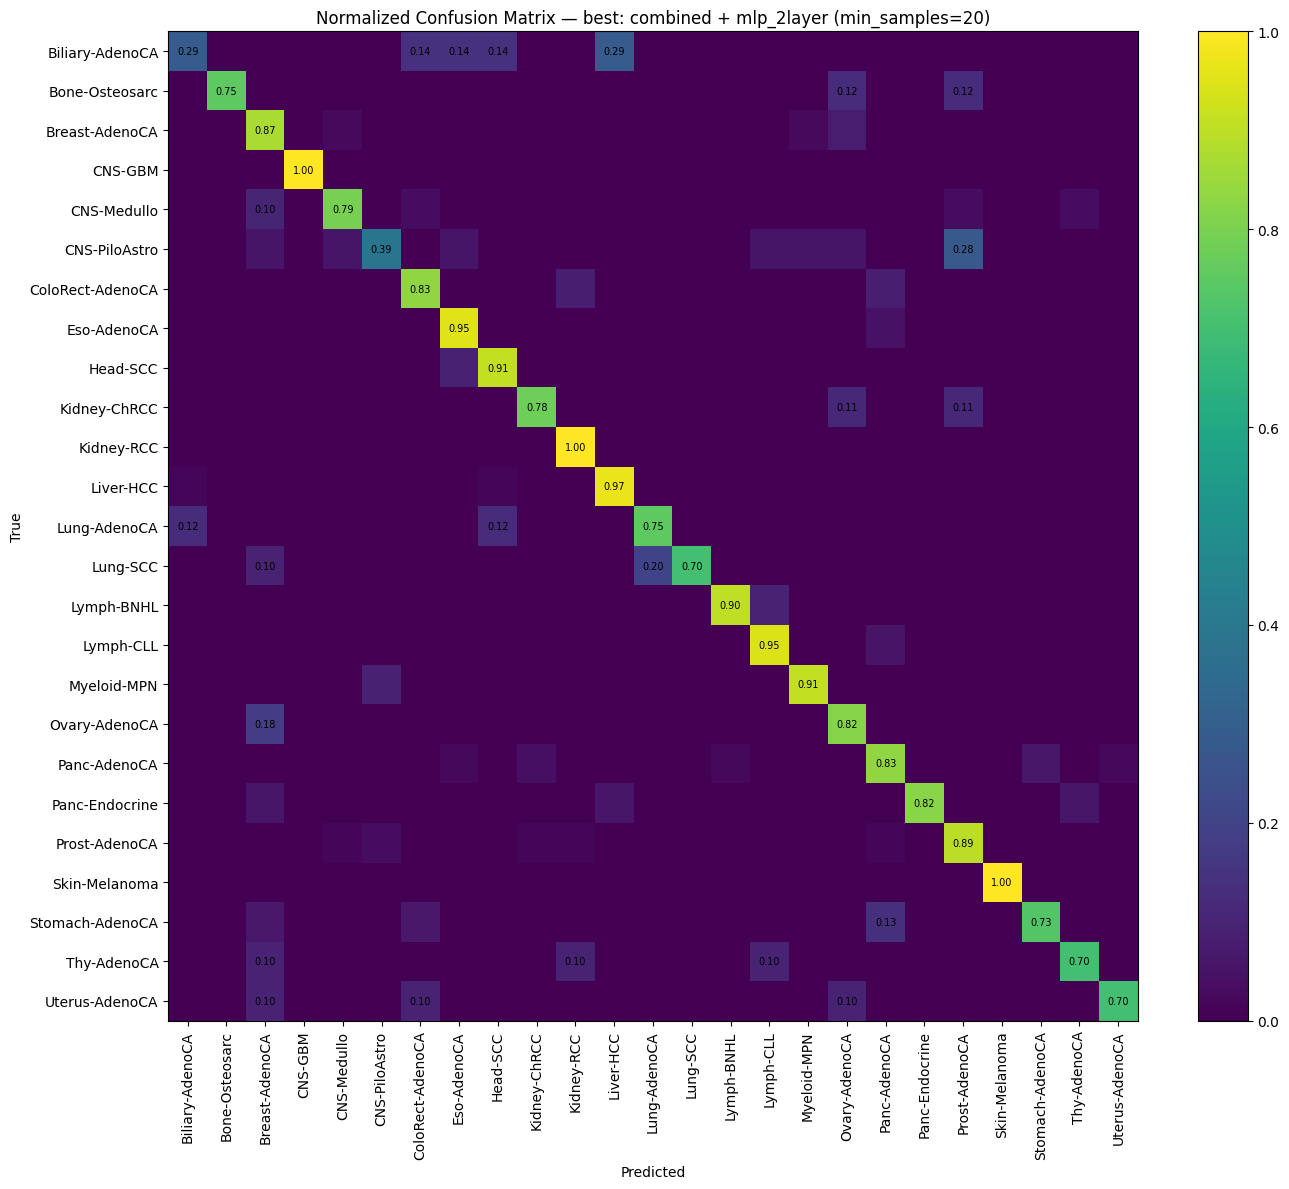

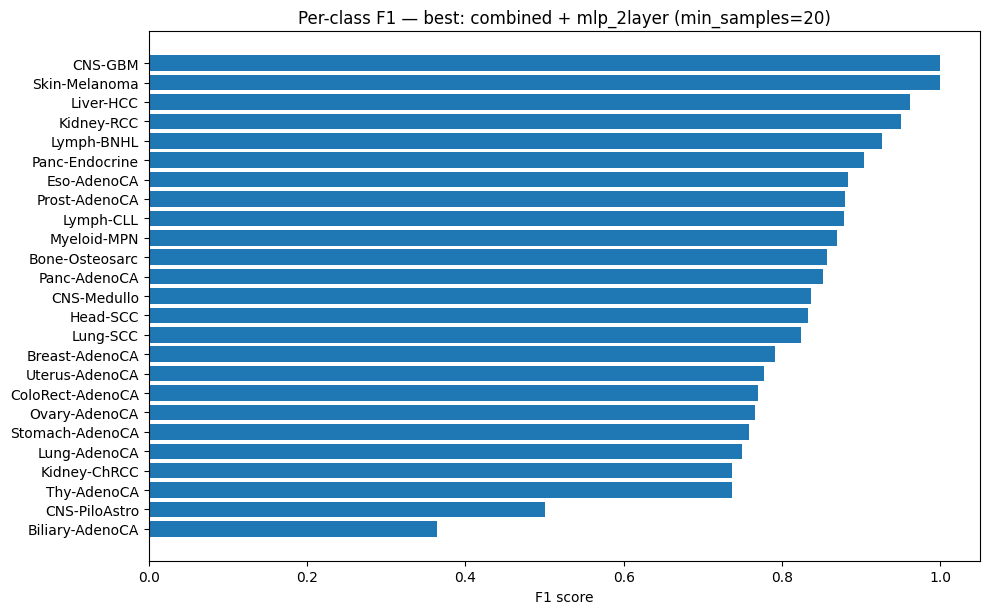

In [22]:
# Model summary table + best model plots (PUT THIS AT THE END)
# - Uses your existing split variables if available
# - Filters rare classes (based on TRAIN only)
# - Robust to dtype/NaN/inf issues
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.neural_network import MLPClassifier

# Optional model
try:
    from sklearn.ensemble import HistGradientBoostingClassifier
    HAS_HGB = True
except Exception:
    HAS_HGB = False


# ---------- 0) fetch variables (supports 2 naming styles) ----------
# Prefer your variables: X_train_p/X_test_p/X_train_c/X_test_c/y_train/y_test
# Fallback: X_train/X_test etc (if someone used a different pipeline)

def _pick_var(*names):
    for n in names:
        if n in globals():
            return globals()[n], n
    return None, None

X_train_p, n1 = _pick_var("X_train_p")
X_test_p,  n2 = _pick_var("X_test_p")
X_train_c, n3 = _pick_var("X_train_c", "X_train")      # fallback
X_test_c,  n4 = _pick_var("X_test_c", "X_test")        # fallback
y_train,   n5 = _pick_var("y_train")
y_test,    n6 = _pick_var("y_test")

missing = []
for obj, name in [(X_train_p,"X_train_p"), (X_test_p,"X_test_p"),
                  (X_train_c,"X_train_c"), (X_test_c,"X_test_c"),
                  (y_train,"y_train"), (y_test,"y_test")]:
    if obj is None:
        missing.append(name)

if missing:
    raise NameError(
        f"Missing vars: {missing}\n"
        "Fix:\n"
        "1) Run the cells that build feature matrices and train/test split first.\n"
        "2) If kernel restarted, use 'Restart & Run All' then rerun this cell.\n"
        "Expected at least: X_train_c, X_test_c, y_train, y_test (and profiles: X_train_p/X_test_p)."
    )

print("Using variables:",
      f"{n1}, {n2}, {n3}, {n4}, {n5}, {n6}")


# ---------- 0.2) make X numeric + safe ----------
def to_float_df(X):
    # Works for DataFrame; if it's np array, convert to DF
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)
    X = X.copy()
    X = X.apply(pd.to_numeric, errors="coerce")
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return X.astype(np.float32)

X_train_p = to_float_df(X_train_p)
X_test_p  = to_float_df(X_test_p)
X_train_c = to_float_df(X_train_c)
X_test_c  = to_float_df(X_test_c)

y_train_arr = np.asarray(y_train)
y_test_arr  = np.asarray(y_test)


# ---------- 0.5) FILTER: remove rare classes based on TRAIN only ----------
min_samples = 20  # <-- adjust here

train_counts = pd.Series(y_train_arr).value_counts()
keep_types = train_counts[train_counts >= min_samples].index

train_mask = pd.Series(y_train_arr).isin(keep_types).values
test_mask  = pd.Series(y_test_arr).isin(keep_types).values

y_train_f = y_train_arr[train_mask]
y_test_f  = y_test_arr[test_mask]

# Use iloc for boolean masks (safer than loc on exotic indices)
X_train_p_f = X_train_p.iloc[train_mask]
X_test_p_f  = X_test_p.iloc[test_mask]
X_train_c_f = X_train_c.iloc[train_mask]
X_test_c_f  = X_test_c.iloc[test_mask]

print("\n=== Filtering small classes ===")
print(f"min_samples (in TRAIN): {min_samples}")
print(f"Train samples: {len(y_train_arr)} -> {len(y_train_f)}")
print(f"Test  samples: {len(y_test_arr)} -> {len(y_test_f)}")
print(f"Kept cancer types: {len(keep_types)} / {len(train_counts)}")


# ---------- 1) evaluation helper ----------
results = []
pred_store = {}  # (feature_set, model_name) -> pred array

def eval_and_record(feature_set, model_name, model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)

    row = {
        "feature_set": feature_set,
        "model": model_name,
        "accuracy": accuracy_score(yte, pred),
        "f1_macro": f1_score(yte, pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(yte, pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(yte, pred, average="macro", zero_division=0),
        "recall_macro": recall_score(yte, pred, average="macro", zero_division=0),
    }
    results.append(row)
    pred_store[(feature_set, model_name)] = pred
    return pred


# ---------- 2) model zoo ----------
def get_models():
    models = {}

    models["svm_rbf"] = make_pipeline(
        StandardScaler(with_mean=True, with_std=True),
        SVC(kernel="rbf", C=5, gamma="scale")
    )

    models["svm_rbf_balanced"] = make_pipeline(
        StandardScaler(with_mean=True, with_std=True),
        SVC(kernel="rbf", C=5, gamma="scale", class_weight="balanced")
    )

    models["linear_svm"] = make_pipeline(
        StandardScaler(with_mean=True, with_std=True),
        LinearSVC(C=2, class_weight="balanced", max_iter=8000)
    )

    models["rf"] = RandomForestClassifier(
        n_estimators=600,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample",
        min_samples_leaf=1
    )

    models["mlp_2layer"] = make_pipeline(
        StandardScaler(with_mean=True, with_std=True),
        MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=500, random_state=42)
    )

    models["mlp_4layer"] = make_pipeline(
        StandardScaler(with_mean=True, with_std=True),
        MLPClassifier(hidden_layer_sizes=(512, 256, 128, 64), max_iter=600, random_state=42)
    )

    if HAS_HGB:
        models["hgb"] = HistGradientBoostingClassifier(random_state=42, early_stopping=False)

    return models

models = get_models()


# ---------- 3) run experiments ----------
for mname, model in models.items():
    eval_and_record("profiles_only", mname, model, X_train_p_f, X_test_p_f, y_train_f, y_test_f)

for mname, model in models.items():
    eval_and_record("combined", mname, model, X_train_c_f, X_test_c_f, y_train_f, y_test_f)


# ---------- 4) summary table ----------
results_df = pd.DataFrame(results).sort_values(["accuracy", "f1_macro"], ascending=False).reset_index(drop=True)

print("\n=== Model Comparison Table (sorted by accuracy, then f1_macro) ===")
display(results_df)

results_df.to_csv("model_comparison_summary.csv", index=False)
print("Saved: model_comparison_summary.csv")


# ---------- 5) best model plots ----------
best_row = results_df.iloc[0]
best_feature_set = best_row["feature_set"]
best_model_name = best_row["model"]
best_pred = pred_store[(best_feature_set, best_model_name)]

print("\n=== Best model ===")
print(best_row.to_dict())

labels_sorted = np.unique(np.concatenate([y_test_f, np.asarray(best_pred)]))

cm = confusion_matrix(y_test_f, best_pred, labels=labels_sorted)
cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(14, 12))
plt.imshow(cm_norm, aspect="auto")
plt.colorbar()
plt.xticks(range(len(labels_sorted)), labels_sorted, rotation=90)
plt.yticks(range(len(labels_sorted)), labels_sorted)
plt.title(f"Normalized Confusion Matrix — best: {best_feature_set} + {best_model_name} (min_samples={min_samples})")
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        val = cm_norm[i, j]
        if val >= 0.10:
            plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()

f1_each = f1_score(y_test_f, best_pred, labels=labels_sorted, average=None, zero_division=0)

order = np.argsort(f1_each)[::-1]
labels_by_f1 = labels_sorted[order]
f1_sorted = f1_each[order]

plt.figure(figsize=(10, max(6, len(labels_by_f1) * 0.25)))
plt.barh(range(len(labels_by_f1)), f1_sorted)
plt.yticks(range(len(labels_by_f1)), labels_by_f1)
plt.gca().invert_yaxis()
plt.xlabel("F1 score")
plt.title(f"Per-class F1 — best: {best_feature_set} + {best_model_name} (min_samples={min_samples})")
plt.tight_layout()
plt.show()

In [23]:
best = models[best_model_name]

if best_feature_set == "combined":
    Xtr, Xte, ytr, yte = X_train_c_f, X_test_c_f, y_train_f, y_test_f
elif best_feature_set == "profiles_only":
    Xtr, Xte, ytr, yte = X_train_p_f, X_test_p_f, y_train_f, y_test_f
else:
    raise ValueError(f"Unknown best_feature_set: {best_feature_set}")

print("[Bridge] best_feature_set =", best_feature_set, "| best_model_name =", best_model_name)

[Bridge] best_feature_set = combined | best_model_name = mlp_2layer


In [24]:
DO_ENSEMBLE = True
N_MODELS = 5
SUBSAMPLE = 0.9

if DO_ENSEMBLE:
    from sklearn.base import clone
    from sklearn.pipeline import Pipeline
    from sklearn.svm import SVC

    final_est = best.steps[-1][1]
    if not isinstance(final_est, SVC):
        print("\n[Ensemble skipped] Best model final estimator is not SVC, so predict_proba ensemble is skipped.")
    else:
        preproc = best[:-1]

        C_best = best.get_params().get("svm__C", 5.0)
        gamma_best = best.get_params().get("svm__gamma", "scale")
        cw_best = best.get_params().get("svm__class_weight", None)

        base_prob_model = Pipeline(steps=list(preproc.steps) + [
            ("svm", SVC(
                kernel="rbf",
                C=C_best,
                gamma=gamma_best,
                class_weight=cw_best,
                probability=True,
                random_state=42
            ))
        ])

        rng = np.random.RandomState(42)
        classes = np.unique(ytr)

        prob_sum = np.zeros((len(Xte), len(classes)), dtype=float)

        for i in range(N_MODELS):
            idx = rng.choice(np.arange(len(Xtr)), size=int(len(Xtr) * SUBSAMPLE), replace=True)
            Xb = Xtr.iloc[idx]
            yb = ytr[idx]

            m = clone(base_prob_model)
            m.fit(Xb, yb)

            prob = m.predict_proba(Xte)

            order = [np.where(m.classes_ == c)[0][0] for c in classes]
            prob_sum += prob[:, order]

        prob_avg = prob_sum / N_MODELS
        pred_ens = classes[np.argmax(prob_avg, axis=1)]

        acc_e = accuracy_score(yte, pred_ens)
        f1m_e = f1_score(yte, pred_ens, average="macro", zero_division=0)
        f1w_e = f1_score(yte, pred_ens, average="weighted", zero_division=0)

        print("\n===== ENSEMBLE TEST performance =====")
        print(f"Ensemble: N_MODELS={N_MODELS}, SUBSAMPLE={SUBSAMPLE}")
        print("Accuracy:", acc_e)
        print("F1 macro:", f1m_e)
        print("F1 weighted:", f1w_e)


[Ensemble skipped] Best model final estimator is not SVC, so predict_proba ensemble is skipped.


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np

Xtr2, Xte2, ytr2, yte2 = Xtr, Xte, ytr, yte

pipe = Pipeline([
    ("quantile", QuantileTransformer(output_distribution="normal", random_state=42)),
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("svm", SVC(kernel="rbf"))
])

param_dist = {
    "quantile__n_quantiles": [100, 200, 300, 500],
    "svm__C": np.logspace(-1, 3, 20),
    "svm__gamma": np.logspace(-5, -1, 25),
    "svm__class_weight": [None, "balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rs2 = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=60,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    error_score="raise"
)

print("[Search v2] start ...")
rs2.fit(Xtr2, ytr2)

print("\nBest params:", rs2.best_params_)
print("Best CV f1_macro:", rs2.best_score_)

best2 = rs2.best_estimator_
pred2 = best2.predict(Xte2)

print("\n===== TEST performance (v2) =====")
print("Accuracy:", accuracy_score(yte2, pred2))
print("F1 macro:", f1_score(yte2, pred2, average="macro", zero_division=0))
print("F1 weighted:", f1_score(yte2, pred2, average="weighted", zero_division=0))
print("\nClassification report:\n", classification_report(yte2, pred2, zero_division=0))

[Search v2] start ...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best params: {'svm__gamma': 0.0031622776601683794, 'svm__class_weight': 'balanced', 'svm__C': 20.6913808111479, 'quantile__n_quantiles': 500}
Best CV f1_macro: 0.8153699540555376

===== TEST performance (v2) =====
Accuracy: 0.8797709923664122
F1 macro: 0.8522880317880841
F1 weighted: 0.8817551197044724

Classification report:
                   precision    recall  f1-score   support

 Biliary-AdenoCA       0.40      0.29      0.33         7
  Bone-Osteosarc       1.00      0.88      0.93         8
  Breast-AdenoCA       0.82      0.85      0.84        39
         CNS-GBM       1.00      1.00      1.00         8
     CNS-Medullo       0.96      0.83      0.89        29
   CNS-PiloAstro       0.53      0.94      0.68        18
ColoRect-AdenoCA       0.77      0.83      0.80        12
     Eso-AdenoCA       0.86      0.95      0.90        20
        Head-SCC       0.64      0.82      0.72        11
    K

[TEST] acc=0.8798 | f1_macro=0.8523 | f1_weighted=0.8818


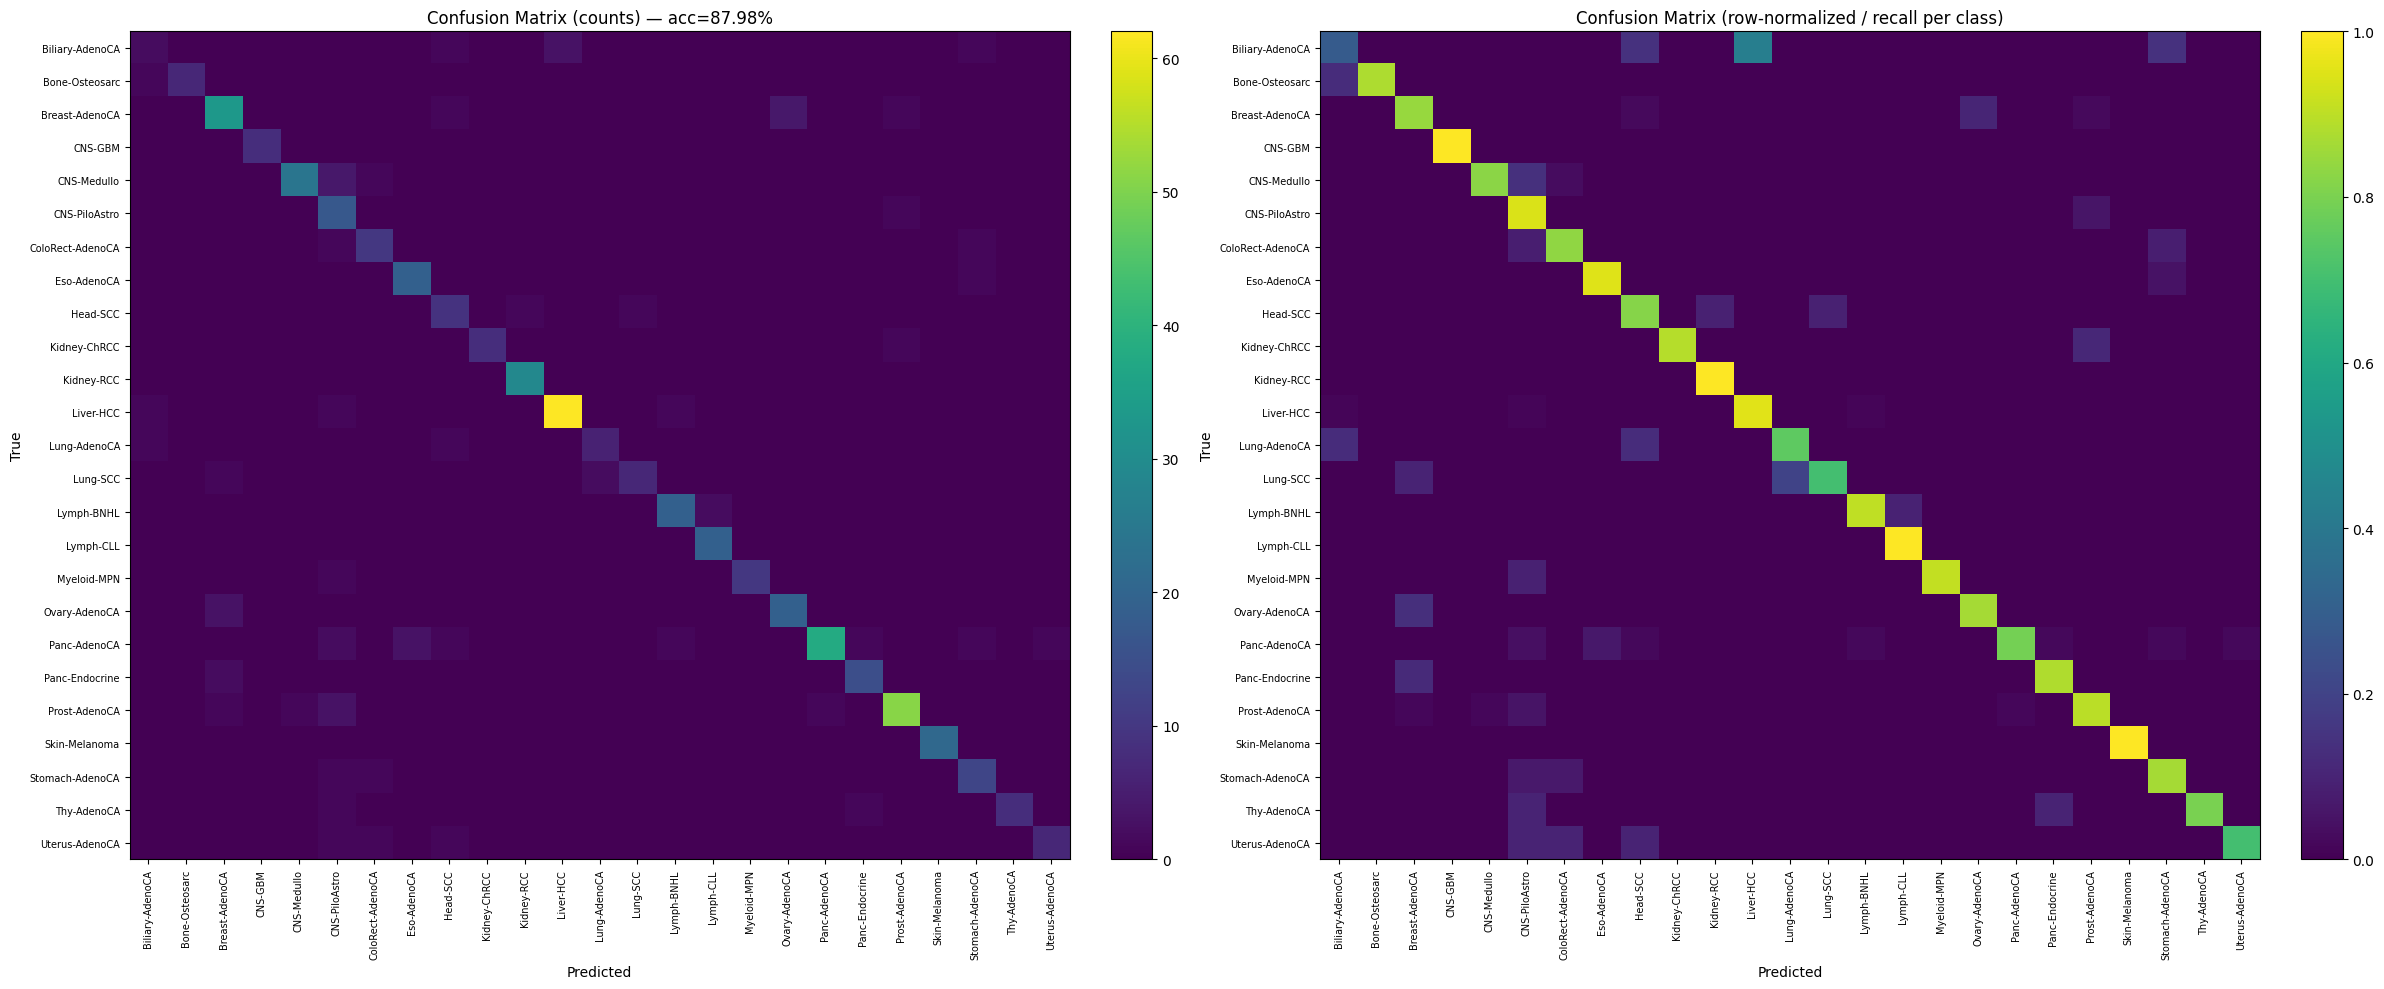

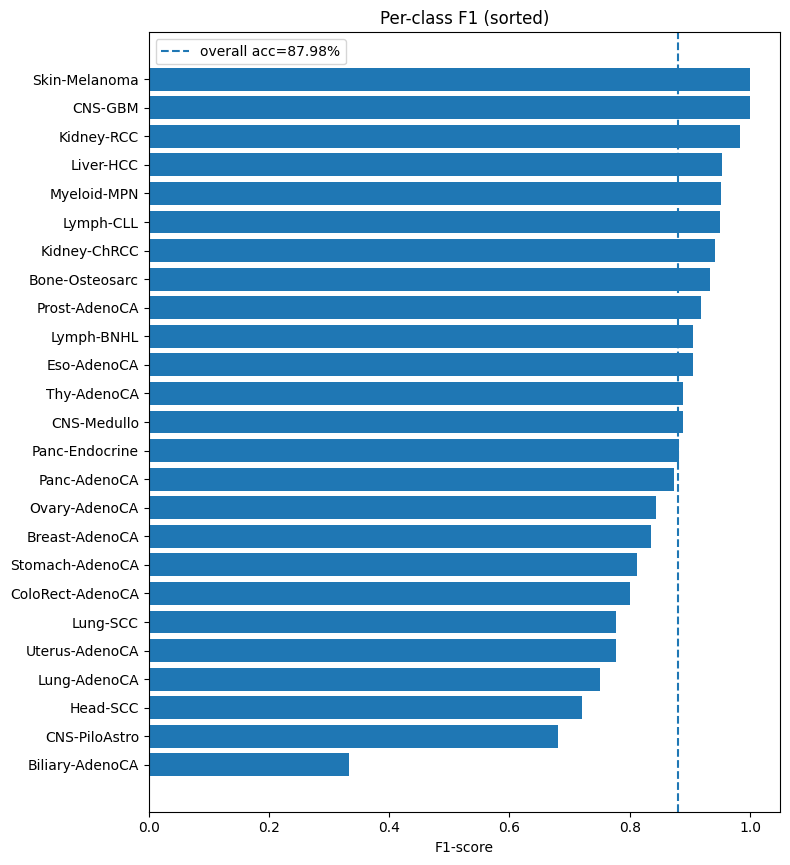


── 5 hardest cancer types ──
                 precision    recall  f1-score  support
Biliary-AdenoCA   0.400000  0.285714  0.333333        7
CNS-PiloAstro     0.531250  0.944444  0.680000       18
Head-SCC          0.642857  0.818182  0.720000       11
Lung-AdenoCA      0.750000  0.750000  0.750000        8
Uterus-AdenoCA    0.875000  0.700000  0.777778       10

── 5 easiest cancer types ──
               precision    recall  f1-score  support
Myeloid-MPN     1.000000  0.909091  0.952381       11
Liver-HCC       0.953846  0.953846  0.953846       65
Kidney-RCC      0.966667  1.000000  0.983051       29
CNS-GBM         1.000000  1.000000  1.000000        8
Skin-Melanoma   1.000000  1.000000  1.000000       21


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix
)

# -----------------------
search_obj = None
for cand in ["rs2", "rs", "random_search", "cv_search"]:
    if cand in globals():
        search_obj = globals()[cand]
        break

best_model = None
for cand in ["best2", "best", "best_estimator"]:
    if cand in globals():
        best_model = globals()[cand]
        break
if best_model is None and search_obj is not None:
    best_model = search_obj.best_estimator_

Xte_use = None
yte_use = None
pred_use = None

for Xn, yn, pn in [
    ("Xte2", "yte2", "pred2"),
    ("Xte", "yte", "best_pred"),
    ("X_test_c", "y_test", "pred_svm"),
]:
    if Xn in globals() and yn in globals():
        Xte_use = globals()[Xn]
        yte_use = globals()[yn]
        if pn in globals():
            pred_use = globals()[pn]
        break

if Xte_use is None or yte_use is None:
    raise NameError("error: no test set variables found (Xte/yte)")

if pred_use is None:
    if best_model is None:
        raise NameError("error: no predictions found and no best_model to predict with")
    pred_use = best_model.predict(Xte_use)

yte_arr = np.array(yte_use)
pred_arr = np.array(pred_use)

acc = accuracy_score(yte_arr, pred_arr)
f1m = f1_score(yte_arr, pred_arr, average="macro", zero_division=0)
f1w = f1_score(yte_arr, pred_arr, average="weighted", zero_division=0)

print(f"[TEST] acc={acc:.4f} | f1_macro={f1m:.4f} | f1_weighted={f1w:.4f}")

# -----------------------
#counts + row-normalized
# -----------------------
labels = np.unique(np.concatenate([yte_arr, pred_arr]))

cm = confusion_matrix(yte_arr, pred_arr, labels=labels)
cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

im0 = axes[0].imshow(cm, aspect="auto")
axes[0].set_title(f"Confusion Matrix (counts) — acc={acc:.2%}")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].set_xticks(range(len(labels))); axes[0].set_yticks(range(len(labels)))
axes[0].set_xticklabels(labels, rotation=90, fontsize=7)
axes[0].set_yticklabels(labels, fontsize=7)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(cm_norm, aspect="auto", vmin=0, vmax=1)
axes[1].set_title("Confusion Matrix (row-normalized / recall per class)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
axes[1].set_xticks(range(len(labels))); axes[1].set_yticks(range(len(labels)))
axes[1].set_xticklabels(labels, rotation=90, fontsize=7)
axes[1].set_yticklabels(labels, fontsize=7)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# -----------------------
# F1 bar hardest/easiest
# -----------------------
rep = classification_report(yte_arr, pred_arr, labels=labels, output_dict=True, zero_division=0)
rep_df = (
    pd.DataFrame(rep).T
    .loc[labels, ["precision", "recall", "f1-score", "support"]]
    .sort_values("f1-score", ascending=True)
)
rep_df["support"] = rep_df["support"].astype(int)

fig, ax = plt.subplots(figsize=(8, max(6, len(labels) * 0.35)))
ax.barh(rep_df.index, rep_df["f1-score"])
ax.axvline(acc, linestyle="--", label=f"overall acc={acc:.2%}")
ax.set_xlabel("F1-score")
ax.set_title("Per-class F1 (sorted)")
ax.legend()
plt.tight_layout()
plt.show()

print("\n── 5 hardest cancer types ──")
print(rep_df.head(5).to_string())
print("\n── 5 easiest cancer types ──")
print(rep_df.tail(5).to_string())